In [1]:
import pandas as pd
from models_conexao_politica import ArticleContent, Article
import json

In [2]:
opiniao_contents = []
with open('data/conexao-politica-opiniao-articles-content.jsonl', 'r') as f:
    for line in f:
        # ATS
        line_dict = json.loads(line)
        line_dict["category"] = "Opinião"
        opiniao_contents.append(ArticleContent.model_validate_json(json.dumps(line_dict)))

analise_contents = []
with open('data/conexao-politica-analise-articles-content.jsonl', 'r') as f:
    for line in f:
        # ATS
        line_dict = json.loads(line)
        line_dict["category"] = "Análise"
        analise_contents.append(ArticleContent.model_validate_json(json.dumps(line_dict)))

In [3]:
dfo = pd.DataFrame([article.model_dump() for article in opiniao_contents])
dfa = pd.DataFrame([article.model_dump() for article in analise_contents])

#display(dfo.head())
#display(dfa.head())

# concat dataframes
df = pd.concat([dfo, dfa], ignore_index=True)
display(df.head())

,title,category,author,date,content,keywords,more_links
0,Lula minimiza papel do governo na alta do gás ...,Opinião,Raul Holderf Nascimento,2025-07-12 09:00:00,O presidente Luiz Inácio Lula da Silva (PT) mi...,"[Economia, Lula, Petrobras]",[https://www.conexaopolitica.com.br/opiniao/qu...
1,Quer ser o novo Nikolas Ferreira?,Opinião,Álvaro Capute,2025-06-07 17:57:25,Hoje eu vou te ensinar como ser o novo Nikolas...,"[Internet, Nikolas ferreira, Redes sociais]",[https://www.conexaopolitica.com.br/opiniao/lu...
2,Ser mãe segundo o coração de Deus: mais do que...,Opinião,Thaís Garcia,2025-05-12 03:00:13,Em uma época de tantos discursos e pouca coerê...,[],[https://www.conexaopolitica.com.br/opiniao/lu...
3,"100 dias de mandato: Trump, tarifas e a arte d...",Opinião,Álvaro Capute,2025-05-02 13:30:03,Enquanto você reclama da falta de engajamento ...,"[Donald trump, Eleições, Estados unidos, Mandato]",[https://www.conexaopolitica.com.br/opiniao/lu...
4,Conservador que chamou petista de &#8216;ladrã...,Opinião,Marcos Rocha,2024-11-26 21:12:10,O ex-deputado estadual e vereador eleito de Ca...,"[Campo grande, Justiça, Ladrao, Lula, Ms, Pt]",[https://www.conexaopolitica.com.br/ultimas/ca...


In [4]:
#  ============= IDEA ==============
#  get all contents, tokenize with spacy, create a word cloud of each keyword
all_contents = dfo['content'].tolist() + dfa['content'].tolist()

display(len(all_contents))

all_keywords = dfo['keywords'].tolist() + dfa['keywords'].tolist()
all_keywords_flat = [keyword for sublist in all_keywords for keyword in sublist]
all_keywords_flat = [keyword.lower() for keyword in all_keywords_flat]
display(len(all_keywords_flat))

from collections import Counter
keyword_counts = Counter(all_keywords_flat)
display(keyword_counts.most_common(20))


675

1795

[('destaque', 226),
 ('jair bolsonaro', 121),
 ('fixo', 48),
 ('coronavírus', 31),
 ('lula', 29),
 ('dpl', 28),
 ('deus', 26),
 ('jesus', 25),
 ('política', 23),
 ('supremo tribunal federal (stf)', 22),
 ('esquerda', 21),
 ('imprensa', 21),
 ('comunismo', 21),
 ('china', 18),
 ('eleições', 17),
 ('covid-19', 15),
 ('governo', 14),
 ('fake news', 14),
 ('conservadorismo', 14),
 ('movimento docentes pela liberdade', 14)]

In [5]:
from IPython.display import clear_output
%pip install spacy
clear_output()

In [6]:
# Baixar o modelo português
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "spacy", "download", "pt_core_news_sm"])

/home/erlo/Documents/Code/pln-2025/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


0

In [7]:
import spacy
from spacy.lang.pt.examples import sentences 

nlp = spacy.load("pt_core_news_sm")

/home/erlo/Documents/Code/pln-2025/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


In [8]:
doc = nlp(df['content'].iloc[0].split('.')[0])
print(doc.text)

print([token.text for token in doc])


O presidente Luiz Inácio Lula da Silva (PT) minimizou nesta sexta-feira (11) a responsabilidade do governo sobre a alta no preço do gás de cozinha nos últimos meses
['O', 'presidente', 'Luiz', 'Inácio', 'Lula', 'da', 'Silva', '(', 'PT', ')', 'minimizou', 'nesta', 'sexta-feira', '(', '11', ')', 'a', 'responsabilidade', 'do', 'governo', 'sobre', 'a', 'alta', 'no', 'preço', 'do', 'gás', 'de', 'cozinha', 'nos', 'últimos', 'meses']


In [9]:
%pip install wordcloud
clear_output()

In [10]:
df['keywords']

0                            [Economia, Lula, Petrobras]
1            [Internet, Nikolas ferreira, Redes sociais]
2                                                     []
3      [Donald trump, Eleições, Estados unidos, Mandato]
4          [Campo grande, Justiça, Ladrao, Lula, Ms, Pt]
                             ...                        
670                                [Globo news, Palocci]
671                                                   []
672             [Fake news, Haddad, Jair bolsonaro, Tse]
673                               [Jair bolsonaro, Vice]
674                                           [Carnaval]
Name: keywords, Length: 675, dtype: object

['jair bolsonaro', 'fixo', 'coronavírus', 'lula', 'esquerda', 'política']


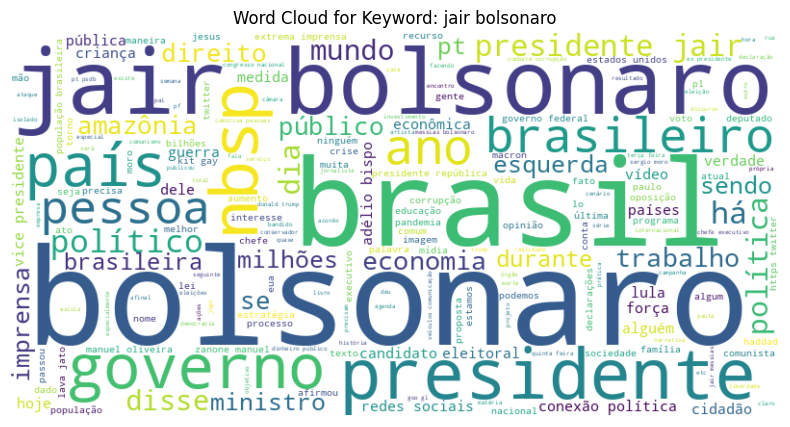

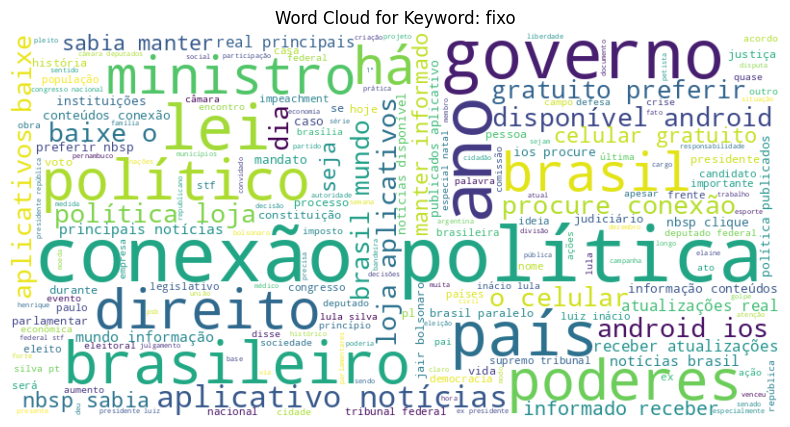

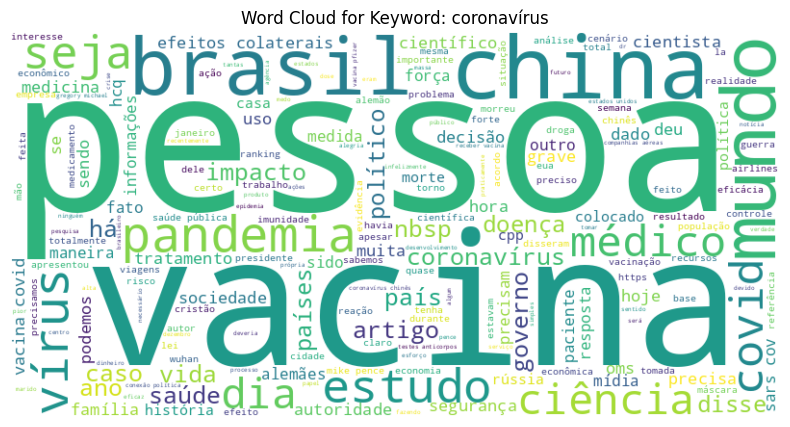

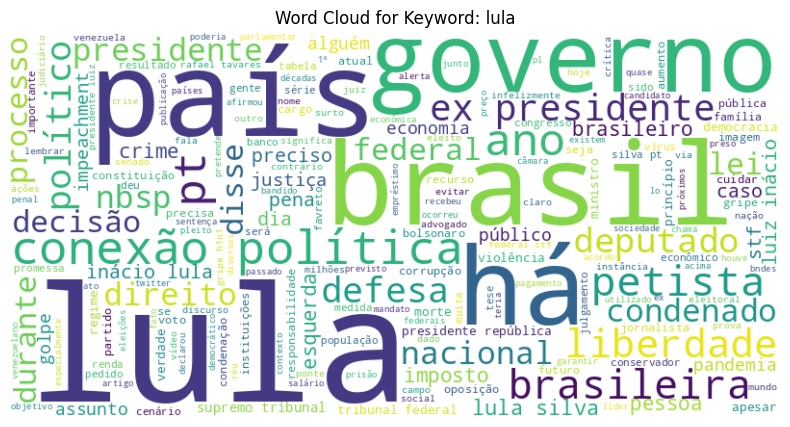

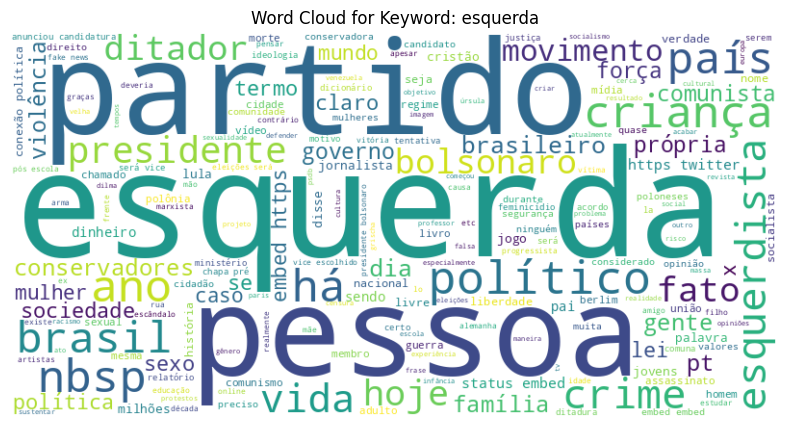

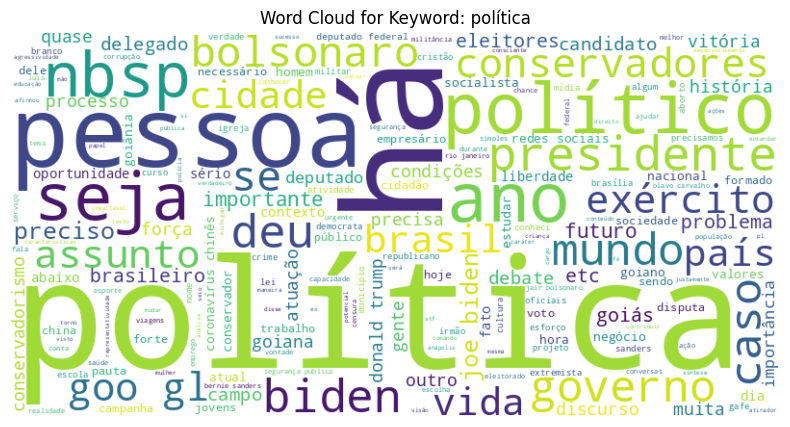

In [11]:
# for the top 5 keywords, 
# - filter the dataframe, 
# - tokenize words, 
# - remove stop words / punctuation
# - create a word cloud of the most common words for each keyword


import matplotlib.pyplot as plt
from wordcloud import WordCloud

top_keywords = [keyword for keyword, count in keyword_counts.most_common(5)]
top_keywords = top_keywords + ['esquerda', 'política']
top_keywords = [kw for kw in top_keywords if kw not in ['destaque']]
print(top_keywords)

for keyword in top_keywords:
    filtered_df = df[df['keywords'].apply(lambda x: keyword in [k.lower() for k in x])]
    all_words = []
    for content in filtered_df['content']:
        doc = nlp(content)
        words = [token.text.lower() for token in doc if not token.is_stop and not token.is_punct]
        all_words.extend(words)
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for Keyword: {keyword}")
    plt.show()

In [15]:
import hashlib
from unidecode import unidecode

def generate_article_id(title: str, category: str, date: str) -> str:
    """
    Gera ID único e semi-explainável para artigos.
    
    Args:
        title: Título do artigo
        category: Categoria do artigo (ex: "Opinião", "Análise")
        date: Data no formato YYYYMMDD
    """
    site_code = "CNXP"
    
    # Slug do título (primeiras palavras, legível)
    normalized_title = unidecode(title.lower())
    words = normalized_title.split()[:3]  # Primeiras 3 palavras
    category_slug = unidecode(category.lower().replace(" ", "_"))
    
    # Hash curto para garantir unicidade (usa título completo)
    hash_input = f"{title}-{category}-{date}"
    hash_short = hashlib.md5(hash_input.encode()).hexdigest()[:8]
    
    return f"{site_code}-{category_slug}-{date}-{hash_short}"

# Teste
print(generate_article_id("Exemplo de Título Político", "Opinião", "20260301"))
print(generate_article_id("Exemplo de Título Político", "Análise", "20260302"))
print(generate_article_id(df['title'].iloc[0], df['category'].iloc[0], "20260301"))

CNXP-opiniao-20260301-013932b6
CNXP-analise-20260302-4303cea0
CNXP-opiniao-20260301-b4899228


In [17]:
df['formatted_date'] = pd.to_datetime(df['date']).dt.strftime('%Y%m%d')
df['id'] = df.apply(lambda row: generate_article_id(row['title'], row['category'], row['formatted_date']), axis=1)
display(df[['id', 'title', 'formatted_date', 'date']].head())

,id,title,formatted_date,date
0,CNXP-opiniao-20250712-a1983d80,Lula minimiza papel do governo na alta do gás ...,20250712,2025-07-12 09:00:00
1,CNXP-opiniao-20250607-61b5a608,Quer ser o novo Nikolas Ferreira?,20250607,2025-06-07 17:57:25
2,CNXP-opiniao-20250512-d13c5d51,Ser mãe segundo o coração de Deus: mais do que...,20250512,2025-05-12 03:00:13
3,CNXP-opiniao-20250502-7491424b,"100 dias de mandato: Trump, tarifas e a arte d...",20250502,2025-05-02 13:30:03
4,CNXP-opiniao-20241126-a4eb0f58,Conservador que chamou petista de &#8216;ladrã...,20241126,2024-11-26 21:12:10


In [18]:
save = True
if save:
    df[['id', 'title', 'content']].to_csv('data/conexao_politica_articles.csv', index=False, sep='|')